Bias and Variance

In [2]:
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [ ]:
#Generate reproducible nonlinear data
np.random.seed(42)

# np.random.normal(0, 5, 40) is to generate random noise
# and add realistic variation to the output data
# np.random.normal( mean, standard_deviation, number_of_values)
x = np.linspace(0, 10, 40).reshape(-1, 1)

y = 2 + 0.5*x[:, 0]**2 + np.random.normal(0, 5, 40)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state = 42)

degrees = [1, 2, 10]

# include_bias = False - is to tell PolynomialFeatures not to create
# an additional constant column containing only 1s.
for degree in degrees:
    
    model = make_pipeline(
        PolynomialFeatures(degree = degree, include_bias = False), #no bias
        LinearRegression()
    )
    
    model.fit(x_train, y_train)
    
    train_prediction = model.predict(x_train)
    test_prediction = model.predict(x_test)

    train_mse = mean_squared_error(y_train, train_prediction)
    test_mse = mean_squared_error(y_test, test_prediction)

    print(f"Polynomial degree : {degree}")
    print(f"Training MSE : {train_mse:.2f}")
    print(f"Testing MSE : {test_mse:.2f}")  #95 for polynomial = 10
    print()

Polynomial degree : 1
Training MSE : 42.90
Testing MSE : 42.99

Polynomial degree : 2
Training MSE : 20.44
Testing MSE : 19.79

Polynomial degree : 10
Training MSE : 18.26
Testing MSE : 38.42



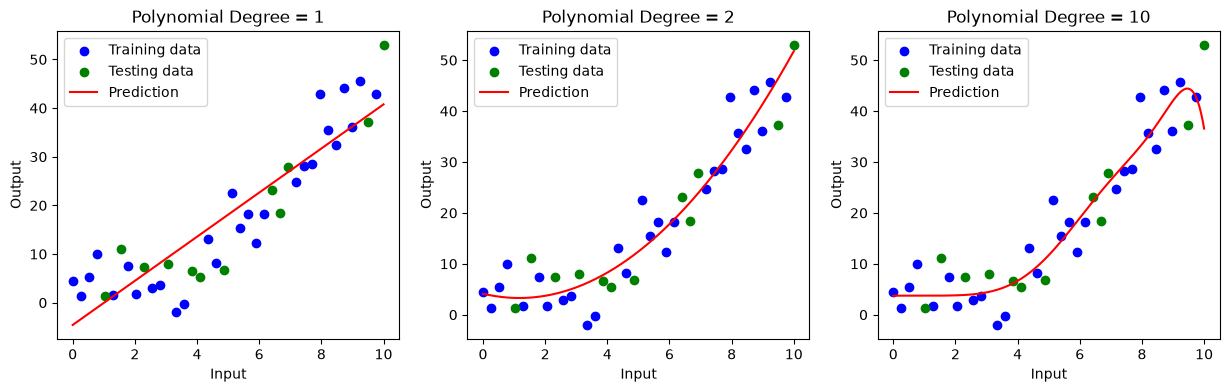

In [15]:
x_plot = np.linspace(0, 10, 200).reshape(-1, 1)

plt.figure(figsize = (15, 4))

for index, degree in enumerate(degrees):
    model = make_pipeline(
        PolynomialFeatures(degree = degree, include_bias = False),
        LinearRegression()
    )
    
    model.fit(x_train, y_train)
    y_plot = model.predict(x_plot)
    
    plt.subplot(1, 3, index + 1)
    plt.scatter(x_train, y_train, color = "blue", label = "Training data")
    plt.scatter(x_test, y_test, color = "green", label = "Testing data")
    plt.plot(x_plot, y_plot, color = "red", label = "Prediction")
    
    plt.title(f"Polynomial Degree = {degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.legend()
    
plt.tight_layout
plt.show()
    

Cross Validation and model selection

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import numpy as np

for degree in range(1, 11):
    model = make_pipeline(
        PolynomialFeatures(degree = degree, include_bias = False),
        LinearRegression()
    )
    
    scores = cross_val_score(
        model,
        x,
        y,
        cv = 5,
        scoring = "neg_mean_squared_error"
        # scikit-learn return the negative value of
        # the Mean Squared Error (MSE)
        # represent better model performance
    )
    
    mean_mse = -scores.mean()
    print(f"Degree {degree}: CV MSE = {mean_mse:.2f}")
    
    

Degree 1: CV MSE = 110.69
Degree 2: CV MSE = 44.22
Degree 3: CV MSE = 71.23
Degree 4: CV MSE = 82.46
Degree 5: CV MSE = 1346.32
Degree 6: CV MSE = 7930.95
Degree 7: CV MSE = 20375.98
Degree 8: CV MSE = 31567.34
Degree 9: CV MSE = 55109.01
Degree 10: CV MSE = 67544.63
